## [pyKNEEr](https://github.com/sbonaretti/pyKNEEr)

# [Segmentation quality](https://sbonaretti.github.io/pyKNEEr/segmentation.html)
Content under Creative Commons Attribution license CC-BY-NC-SA 4.0   
Code under GNU-GPL v3 License  
© 2019 Serena Bonaretti
---

Segmentation quality is evaluated using 3 measures of *overlap agreement* [1]:  
- Dice coefficient  
- Jaccard coefficient 
- Volume similarity  

and 1 measure of *surface distance*:
- Average Euclidean distance

---

## Import packages

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pykneer import pykneer_io                  as io
from pykneer import segmentation_quality_for_nb as sq

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


## Image information

Input and output:   
- `input_file_name` contains the list of the masks segmented using pyKNEEr and of ground truth masks
- `output_file_name` contains the table of the overlap coefficients

In [3]:
# input_file_name  = "./image_list_segmentation_quality_OAI1_DESS.txt" # commented out because downloaded from GitHub
input_file_name            = "segmentation_quality.txt"
output_file_name_overlap   = "output_file_overlap_here.csv"
output_file_name_distances = "output_file_distance_here.csv"

---

## Reloading overlap coefficients

In [4]:
import pandas as pd
import os

def read_overlap_coeff_table(input_file_name):
    """
    Read the CSV file created by overlap_coeff_table() and reconstruct the original variables.
    """

    # read CSV file
    table = pd.read_csv(input_file_name)

    # extract values from columns
    image_names = table["subjects"].tolist()
    dice_coeff = table["dice_coeff"].tolist()
    jacc_coeff = table["jaccard_coeff"].tolist()
    vol_simil = table["volume_similarity"].tolist()

    # rebuild all_image_data structure
    all_image_data = []
    for name in image_names:
        # ensure the name is a string before concatenation
        segmented_name = str(name) + ".nii"
        all_image_data.append({"segmented_name": segmented_name})

    print("Data successfully loaded from:", input_file_name)

    return all_image_data, dice_coeff, jacc_coeff, vol_simil



image_data, dice_coeff, jacc_coeff, vol_simil = read_overlap_coeff_table(output_file_name_overlap)

Data successfully loaded from: output_file_overlap_here.csv


## Visualizing overlap coefficients

The values of overlap coefficient are visualized as:
- a GRAPH, to visually observe the trend of the dataset 
- a TABLE, to observe the numerical values

#### GRAPH: Dots represent the coefficient value

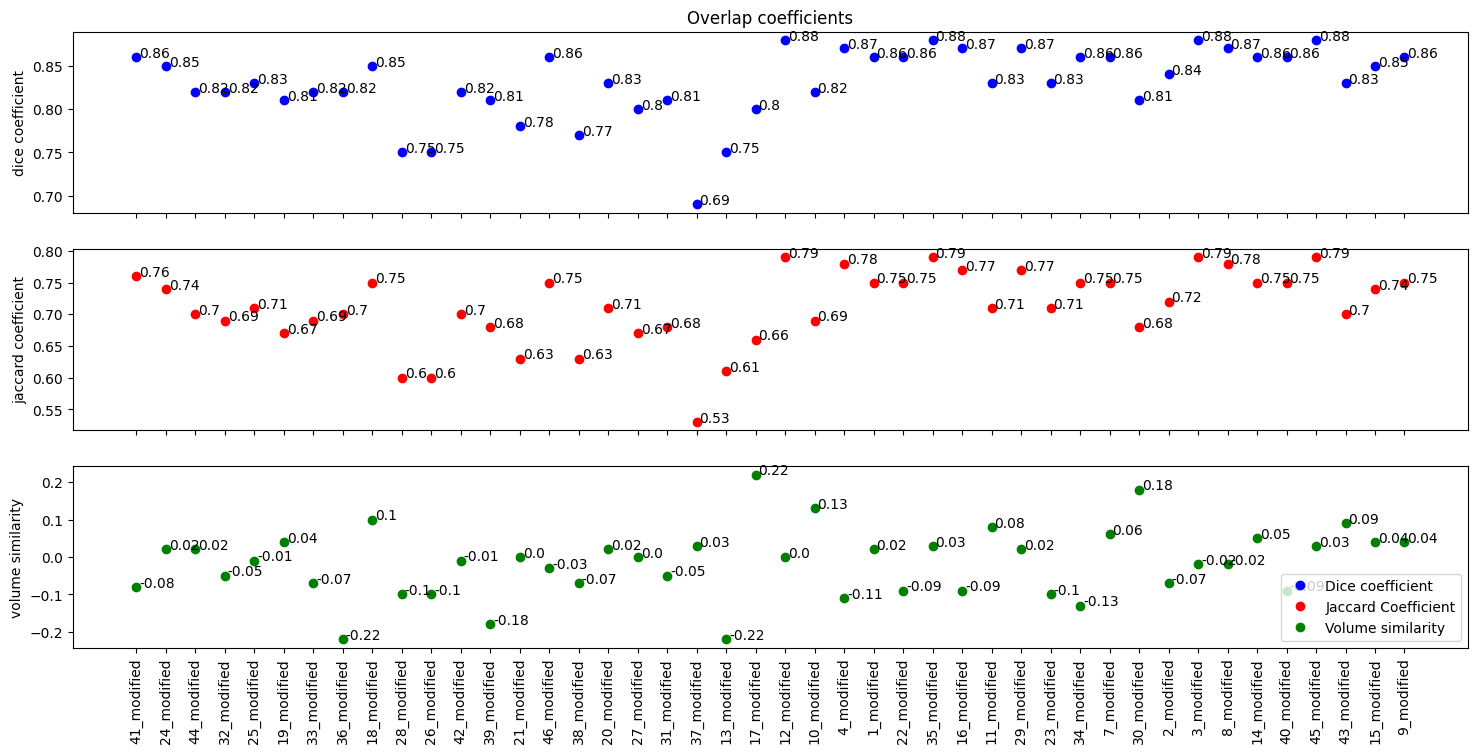

In [5]:
sq.overlap_coeff_graph(image_data, dice_coeff, jacc_coeff, vol_simil)

#### TABLE: Overlap coefficients per image
The table is saved as a .csv file for subsequent analyisis

In [6]:
coeff = sq.overlap_coeff_table(image_data, dice_coeff, jacc_coeff, vol_simil, output_file_name_overlap)
display(coeff)

Table saved as: output_file_overlap_here.csv


,subjects,dice_coeff,jaccard_coeff,volume_similarity
1,41_modified,0.86,0.76,-0.08
2,24_modified,0.85,0.74,0.02
3,44_modified,0.82,0.70,0.02
4,32_modified,0.82,0.69,-0.05
5,25_modified,0.83,0.71,-0.01
6,19_modified,0.81,0.67,0.04
7,33_modified,0.82,0.69,-0.07
8,36_modified,0.82,0.70,-0.22
9,18_modified,0.85,0.75,0.10
10,28_modified,0.75,0.60,-0.10


---

## Reloading surface distances

In [7]:
import pandas as pd
import os

def read_surface_distance_table(input_file_name):
    """
    Read the CSV file created by surface_distance_table() and reconstruct the original variables.
    """

    # read CSV file
    table = pd.read_csv(input_file_name)

    # extract values from columns
    image_names = table["subjects"].tolist()
    mean_distances = table["mean_distances"].tolist()
    stddev_distances = table["stddev_distances"].tolist()

    # rebuild all_image_data structure
    all_image_data = []
    for name in image_names:
        # ensure the name is a string before concatenation
        segmented_name = str(name) + ".nii"
        all_image_data.append({"segmented_name": segmented_name})

    print("Data successfully loaded from:", input_file_name)

    return all_image_data, mean_distances, stddev_distances

image_data, mean_distances, stddev_distances = read_surface_distance_table(output_file_name_distances)


Data successfully loaded from: output_file_distance_here.csv


## Visualizing surface distances

The values of surface distances are visualized as:
- a GRAPH, to visually observe the trend of the dataset 
- a TABLE, to observe the numerical values

#### GRAPH: Dots represent the mean surface distance

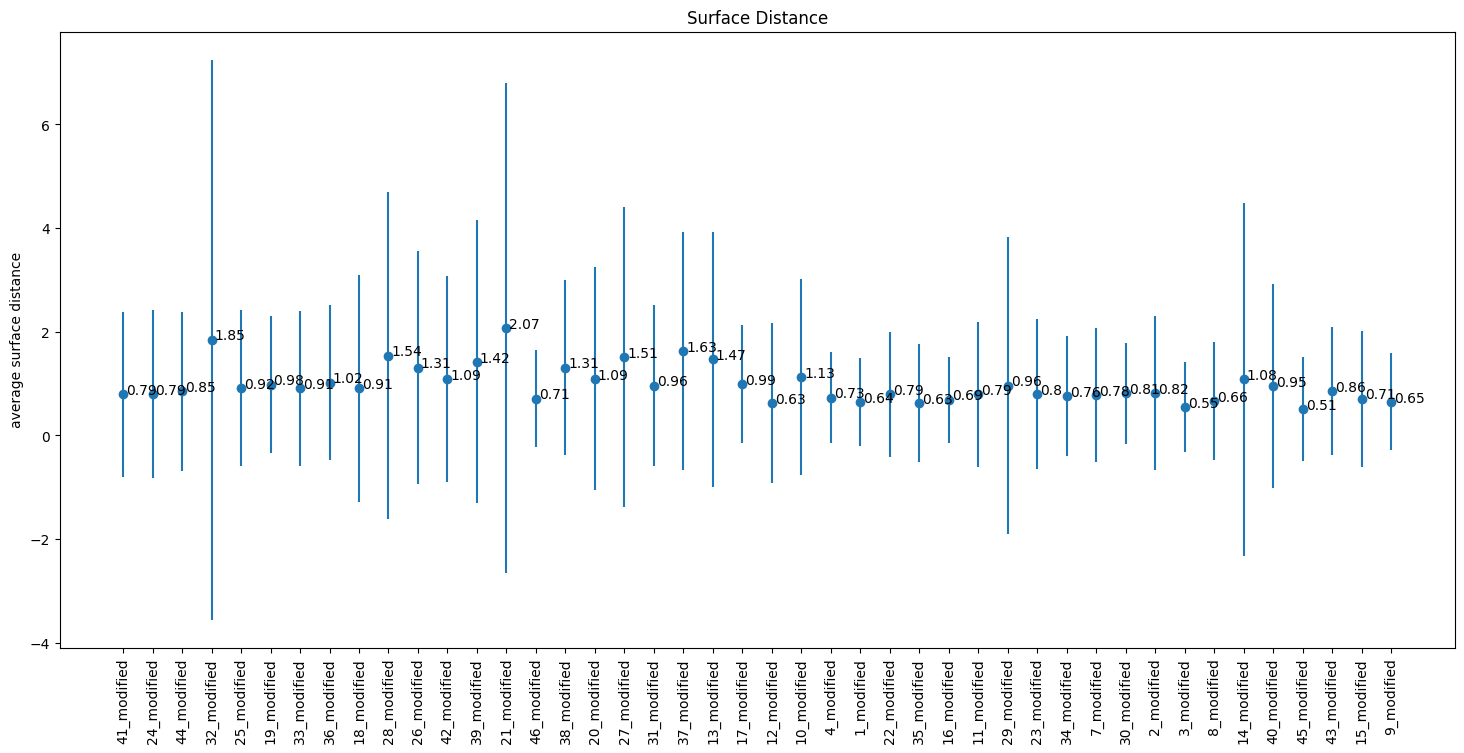

In [8]:
sq.surface_distance_graph(image_data, mean_distances, stddev_distances)

#### TABLE: Average distances per image
The table is saved as a .csv file for subsequent analyisis

In [9]:
table = sq.surface_distance_table(image_data, mean_distances, stddev_distances, output_file_name_distances)
display(table)

Table saved as: output_file_distance_here.csv


,subjects,mean_distances,stddev_distances
1,41_modified,0.79,1.60
2,24_modified,0.79,1.62
3,44_modified,0.85,1.53
4,32_modified,1.85,5.40
5,25_modified,0.92,1.50
6,19_modified,0.98,1.32
7,33_modified,0.91,1.49
8,36_modified,1.02,1.49
9,18_modified,0.91,2.19
10,28_modified,1.54,3.15


---

### References

[1] Tustison N.J., Gee J.C. [*Introducing Dice, Jaccard, and Other Label Overlap Measures To ITK*](http://insight-journal.org/browse/publication/707) The Insight Journal. July-December. 2009.

### Dependencies

In [10]:
%load_ext watermark
%watermark -v -m -p pykneer,SimpleITK,matplotlib,numpy,pandas
print (" ")
%watermark -u -n -t -z

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.5.0

pykneer   : unknown
SimpleITK : 2.5.2
matplotlib: 3.10.6
numpy     : 2.2.6
pandas    : 2.3.2

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 32
Architecture: 64bit

 
Last updated: Tue Oct 14 2025 18:32:29ora legale Europa occidentale

